# Лабораторная работа № 3

# Предварительная обработка данных

**Цель работы:** познакомиться с теоретическими принципами и инструментальными средствами предварительной обработки данных.

Проанализируем датасет football. Датасет содержит статистику команд в футбольном турнире. Признаки включают игровые показатели, а также категориальные атрибуты. Данные предназначены для анализа влияния различных факторов на результативность команд. Набор данных включает следующие атрибуты:
- **Team** – название команды;
- **Goals** – забитые голы;
- **Shots on target** – удары в створ ворот;
- **Shots off target** – удары мимо ворот;
- **Shooting Accuracy** – точность ударов;
- **% Goals-to-shots** – процент голов от ударов;
- **Total shots (inc. Blocked)** – всего ударов (включая заблокированные);
- **Hit Woodwork** – попадания в штангу/перекладину;
- **Penalty goals** – голы с пенальти;
- **Penalties not scored** – нереализованные пенальти;
- **Headed goals** – голы головой;
- **Passes** – пасы;
- **Passes completed** – точные пасы;
- **Passing Accuracy** – точность пасов;
- **Touches** – касания мяча;
- **Crosses** – навесы;
- **Dribbles** – обводки;
- **Corners Taken** – угловые;
- **Tackles** – отборы;
- **Clearances** – выносы мяча;
- **Interceptions** – перехваты;
- **Clearances off line** – выносы с линии ворот;
- **Clean Sheets** – "сухие" матчи;
- **Blocks** – блокировки ударов;
- **Goals conceded** – пропущенные голы;
- **Saves made** – сейвы;
- **Saves-to-shots ratio** – процент сейвов;
- **Fouls Won** – заработанные фолы;
- **Fouls Conceded** – совершенные фолы;
- **Offsides** – офсайды;
- **Yellow Cards** – желтые карточки;
- **Red Cards** – красные карточки;
- **Subs on** – замены на выход;
- **Subs off** – замены на вход;
- **Players Used** – использованные игроки.

# 0. Импортируем необходимые библиотеки

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем набор данных из файла football.csv и помещаем его в объект DataFrame

In [4]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('football.csv')

Saving football.csv to football (1).csv


# 2. Выведем 5 первых строк

In [6]:
df.head()

,Team,Goals,Shots on target,Shots off target,Shooting Accuracy,% Goals-to-shots,Total shots (inc. Blocked),Hit Woodwork,Penalty goals,Penalties not scored,...,Saves made,Saves-to-shots ratio,Fouls Won,Fouls Conceded,Offsides,Yellow Cards,Red Cards,Subs on,Subs off,Players Used
0,Croatia,4,13,12,51.9%,16.0%,32,0,0,0,...,13,81.3%,41,62,2,9,0,9,9,16
1,Czech Republic,4,13,18,41.9%,12.9%,39,0,0,0,...,9,60.1%,53,73,8,7,0,11,11,19
2,Denmark,4,10,10,50.0%,20.0%,27,1,0,0,...,10,66.7%,25,38,8,4,0,7,7,15
3,England,5,11,18,50.0%,17.2%,40,0,0,0,...,22,88.1%,43,45,6,5,0,11,11,16
4,France,3,22,24,37.9%,6.5%,65,1,0,0,...,6,54.6%,36,51,5,6,0,11,11,19


> Видим, что в датасете 16 команд и 35 столбцов. Все столбцы содержат числовые или текстовые данные. Пропусков в первых 5 строках не видно.

# 3. Базовые методы обнаружения пропущенных значений

## Метод .info()


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Team                        16 non-null     object 
 1   Goals                       16 non-null     int64  
 2   Shots on target             16 non-null     int64  
 3   Shots off target            16 non-null     int64  
 4   Shooting Accuracy           16 non-null     object 
 5   % Goals-to-shots            16 non-null     object 
 6   Total shots (inc. Blocked)  16 non-null     int64  
 7   Hit Woodwork                16 non-null     int64  
 8   Penalty goals               16 non-null     int64  
 9   Penalties not scored        16 non-null     int64  
 10  Headed goals                16 non-null     int64  
 11  Passes                      16 non-null     int64  
 12  Passes completed            16 non-null     int64  
 13  Passing Accuracy            16 non-nu

>Всего в датасете 16 записей и 35 столбцов. Метод .info() показывает, что в 15 столбцах  16 non-null, т.е формально пропусков в них нет. Типы данных float64(1) int64(29) object(5).

## Методы .isna() и .sum()


In [8]:
df.isna().sum()

,0
Team,0
Goals,0
Shots on target,0
Shots off target,0
Shooting Accuracy,0
% Goals-to-shots,0
Total shots (inc. Blocked),0
Hit Woodwork,0
Penalty goals,0
Penalties not scored,0


> Метод .isna().sum() показывает, что в столбце Clearances off line 1 пропущенное значение (у команды Croatia). В остальных столбцах пропусков нет.

## Процент пропущенных значений

In [9]:
(df.isna().sum() / len(df)).round(4) * 100

,0
Team,0.00
Goals,0.00
Shots on target,0.00
Shots off target,0.00
Shooting Accuracy,0.00
% Goals-to-shots,0.00
Total shots (inc. Blocked),0.00
Hit Woodwork,0.00
Penalty goals,0.00
Penalties not scored,0.00


> Процент пропущенных значений в столбце Clearances off line составляет 6.25% (1 из 16 записей). В остальных столбцах пропусков нет.

## Матрица корреляции пропущенных значений

Матрица корреляции пропущенных значений показывает, насколько сильно присутствие или отсутствие значений одного признака влияет на присутствие значений другого. В моём датасете пропуски содержатся только в одном столбце — Clearances off line, поэтому построить матрицу корреляции пропусков невозможно (для этого нужно минимум 2 столбца с пропусками).

# 4. Стратегии работы с пропусками

## Удаление строк

В столбце Clearances off line 1 пропущенное значение (6.25%). Это небольшой процент, поэтому можно удалить соответствующую строку без значительной потери данных.

In [10]:
df.dropna(axis='index', subset=['Clearances off line'], inplace=True)

Проверяем, что в столбце Clearances off line больше не осталось пропусков.

In [11]:
df['Clearances off line'].isna().sum()

np.int64(0)

## Удаление столбцов

Удаление столбцов применяется, когда в столбце большой процент пропусков (например, более 50%). В моем датасете пропуски содержатся только в столбце Clearances off line и составляют 6.25%, поэтому удалять столбцы нет необходимости.

## Заполнение пропусков

Рассмотрим различные способы заполнения пропусков. Подготовим данные.

In [15]:
# Загружаем датасет заново
df = pd.read_csv("football (1).csv")

# Возьмем лишь некоторые из столбцов для наглядности
df = df[['Team', 'Goals', 'Shots on target', 'Passes', 'Touches', 'Clearances off line', 'Yellow Cards', 'Red Cards']]

# Посмотрим на результат
df.head()

,Team,Goals,Shots on target,Passes,Touches,Clearances off line,Yellow Cards,Red Cards
0,Croatia,4,13,1076,1706,NaN,9,0
1,Czech Republic,4,13,1565,2358,2.0,7,0
2,Denmark,4,10,1298,1873,0.0,4,0
3,England,5,11,1488,2440,1.0,5,0
4,France,3,22,2066,2909,0.0,6,0


### Заполнение константой

Самый простой способ работы с пропусками в количественных данных — заполнить их константой. Например, нулём. Воспользуемся методом .fillna().

In [13]:
fillna_const = df.copy()

# Заполним пропуски в столбце Clearances off line нулями
fillna_const.fillna({'Clearances off line' : 0}, inplace=True)

Сравним медианное значение количества выносов с линии ворот до и после заполнения пропусков нулями.

In [22]:
df['Clearances off line'].median(), fillna_const['Clearances off line'].median()

(0.0, 0.0)

> Медианное значение количества выносов с линии ворот до заполнения — 0.0, после заполнения нулями — 0.0. В данном датасете у большинства команд значение этого показателя равно 0 (выносы с линии ворот — достаточно редкое событие), поэтому медиана осталась неизменной. Заполнение пропуска нулём в данном случае не исказило центральную тенденцию данных, так как ноль является наиболее частотным значением.

### Заполнение средним арифметическим

Количественные данные можно заполнить средним арифметическим. Воспользуемся методом .fillna().

In [23]:
# Сделаем копию датафрейма
fillna_mean = df.copy()

# Заполним пропуски в столбце Clearances off line средним арифметическим значением
fillna_mean['Clearances off line'] = fillna_mean['Clearances off line'].fillna(fillna_mean['Clearances off line'].mean())

Убедимся, что пропусков не осталось.

In [24]:
fillna_mean['Clearances off line'].isna().sum()

np.int64(0)

Сравним среднее арифметическое значение количества выносов с линии ворот до и после заполнения пропусков средним арифметическим.

In [25]:
df['Clearances off line'].mean(), fillna_mean['Clearances off line'].mean()

(np.float64(0.3333333333333333), np.float64(0.33333333333333337))

> Среднее арифметическое значение количества выносов с линии ворот до заполнения — 0.33, после заполнения средним арифметическим — 0.33. Значение не изменилось, так как пропуск был заполнен именно средним арифметическим.

### Заполнение медианой

In [26]:
# Сделаем копию датафрейма
fillna_median = df.copy()

# Заполним пропуски в столбце Clearances off line медианным значением
fillna_median['Clearances off line'] = fillna_median['Clearances off line'].fillna(fillna_median['Clearances off line'].median())

Убедимся, что пропусков не осталось.

In [27]:
fillna_median['Clearances off line'].isna().sum()

np.int64(0)

Сравним медианное значение количества выносов с линии ворот до и после заполнения пропусков медианой.

In [28]:
df['Clearances off line'].median(), fillna_median['Clearances off line'].median()

(0.0, 0.0)

> Медианное значение количества выносов с линии ворот до и после заполнения медианой — 0.0. Медиана не изменилась, так как пропуск был заполнен именно медианным значением. Заполнение медианой в данном случае является хорошим выбором, так как 0 — наиболее частотное значение в столбце.

### Заполнение наиболее частотным значением

Для заполнения пропусков в категориальных данных подходит метод заполнения наиболее часто встречающимся значением (модой). Если пропусков немного, этот метод вполне обоснован. В моём датасете пропусков в категориальных столбцах нет, поэтому продемонстрируем этот метод на столбце Clearances off line.

In [29]:
# Сделаем копию датафрейма
fillna_mode = df.copy()

# Найдем моду (наиболее часто встречающееся значение)
mode_value = fillna_mode['Clearances off line'].mode()[0]

# Заполним пропуски модой
fillna_mode['Clearances off line'] = fillna_mode['Clearances off line'].fillna(mode_value)

Сравним медианное значение количества выносов с линии ворот до и после заполнения пропусков модой.

In [30]:
df['Clearances off line'].median(), fillna_mode['Clearances off line'].median()

(0.0, 0.0)

> Медианное значение количества выносов с линии ворот до и после заполнения модой — 0.0. Мода (наиболее часто встречающееся значение) в данном столбце равна 0, поэтому заполнение пропуска модой эквивалентно заполнению нулём. Это логично, так как большинство команд не совершали выносов с линии ворот за турнир (10 команд имеют значение 0, 5 команд имеют значение 1).

# 5. Кодирование категориальных переменных

In [31]:
df = fillna_mode.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Team                 16 non-null     object 
 1   Goals                16 non-null     int64  
 2   Shots on target      16 non-null     int64  
 3   Passes               16 non-null     int64  
 4   Touches              16 non-null     int64  
 5   Clearances off line  16 non-null     float64
 6   Yellow Cards         16 non-null     int64  
 7   Red Cards            16 non-null     int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 1.1+ KB


> В датафрейме 16 записей, пропусков нет.

Отдельные категории можно посмотреть с помощью метода .unique().

In [32]:
df.Team.unique()

array(['Croatia', 'Czech Republic', 'Denmark', 'England', 'France',
       'Germany', 'Greece', 'Italy', 'Netherlands', 'Poland', 'Portugal',
       'Republic of Ireland', 'Russia', 'Spain', 'Sweden', 'Ukraine'],
      dtype=object)

> В датасете 16 уникальных названий команд.

С помощью методов .value_counts() библиотеки Pandas и np.unique() библиотеки Numpy можно посмотреть и количество объектов в каждой категории.

In [33]:
df.Team.value_counts()

,count
Team,
Croatia,1
Czech Republic,1
Denmark,1
England,1
France,1
Germany,1
Greece,1
Italy,1
Netherlands,1


In [34]:
np.unique(df.Team, return_counts=True)

(array(['Croatia', 'Czech Republic', 'Denmark', 'England', 'France',
        'Germany', 'Greece', 'Italy', 'Netherlands', 'Poland', 'Portugal',
        'Republic of Ireland', 'Russia', 'Spain', 'Sweden', 'Ukraine'],
       dtype=object),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

> Все 16 команд уникальны.

Последовательное применение методов .value_counts() и .count() выведет общее количество уникальных категорий.

In [35]:
df.Team.value_counts().count()

np.int64(16)

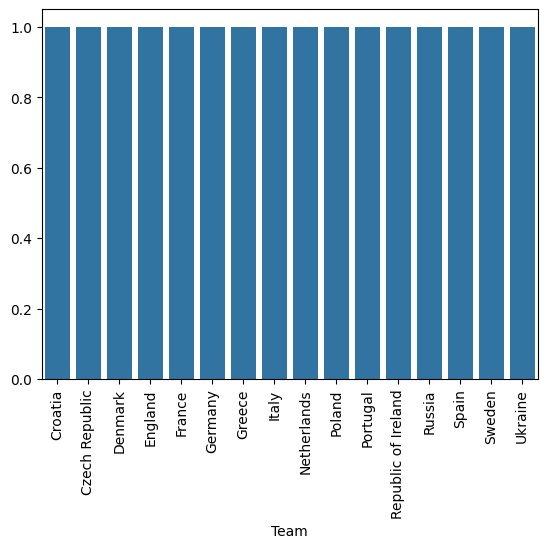

In [37]:
team_counts = df.Team.value_counts()
sns.barplot(x=team_counts.index, y=team_counts.values)
plt.xticks(rotation=90)
plt.show()

> На графике видно, что каждая команда представлена ровно одним наблюдением. Это означает, что датасет содержит агрегированную статистику по каждой команде за турнир, а не построчные данные по матчам.

## Тип данных category

Хорошая практика — перевести категориальную переменную в тип данных category. Если категорий много, то это ускоряет работу с ними и уменьшает использование памяти. Можно воспользоваться методом .astype().

In [38]:
df = df.astype({'Team' : 'category'})

Убедимся, что нужные нам признаки преобразованы в тип category.

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Team                 16 non-null     category
 1   Goals                16 non-null     int64   
 2   Shots on target      16 non-null     int64   
 3   Passes               16 non-null     int64   
 4   Touches              16 non-null     int64   
 5   Clearances off line  16 non-null     float64 
 6   Yellow Cards         16 non-null     int64   
 7   Red Cards            16 non-null     int64   
dtypes: category(1), float64(1), int64(6)
memory usage: 1.7 KB


> Столбец Team преобразован в тип category. Тип category ускоряет работу с категориальными данными и уменьшает использование памяти.

## Базовые методы кодирования

### Кодирование через cat.codes

Кодировать категориальную переменную можно через атрибут cat.codes.

In [40]:
df_cat = df.copy()
df_cat.Team.cat.codes

,0
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7
8,8
9,9


Применим коды к столбцу Team и выведем датафрейм.

In [41]:
df_cat.Team = df_cat.Team.cat.codes
df_cat.head()

,Team,Goals,Shots on target,Passes,Touches,Clearances off line,Yellow Cards,Red Cards
0,0,4,13,1076,1706,0.0,9,0
1,1,4,13,1565,2358,2.0,7,0
2,2,4,10,1298,1873,0.0,4,0
3,3,5,11,1488,2440,1.0,5,0
4,4,3,22,2066,2909,0.0,6,0


> Столбец Team закодирован числовыми кодами от 0 до 15. Коды присваиваются автоматически в порядке следования категорий в датафрейме (по алфавиту).

## Mapping

Суть способа в том, чтобы передать схему кодирования в виде словаря в функцию map() и применить к соответствующему столбцу.

In [44]:
df_map = df.copy()
map_dict = {team: idx for idx, team in enumerate(df_map.Team.unique())}
df_map['Team'] = df_map['Team'].map(map_dict)
df_map.head()

,Team,Goals,Shots on target,Passes,Touches,Clearances off line,Yellow Cards,Red Cards
0,0,4,13,1076,1706,0.0,9,0
1,1,4,13,1565,2358,2.0,7,0
2,2,4,10,1298,1873,0.0,4,0
3,3,5,11,1488,2440,1.0,5,0
4,4,3,22,2066,2909,0.0,6,0


## OneHotEncoding

Категории, в которых больше двух классов, но нет внутренней иерархии, называются номинальными данными. Номинальные данные нельзя заменять числами, так как построенная на основе преобразованных данных модель может подумать, что между категориями есть иерархия, когда в действительности ее нет. Нужно использовать OneHotEncoding.

In [45]:
from sklearn.preprocessing import OneHotEncoder

df_enc = df.copy()

# Создаем энкодер
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Применяем энкодер к столбцу Team
encoded_array = encoder.fit_transform(df_enc[['Team']])

# Создаем датафрейм с новыми столбцами
df_encoded = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['Team'])
)
df_encoded.head()

,Team_Croatia,Team_Czech Republic,Team_Denmark,Team_England,Team_France,Team_Germany,Team_Greece,Team_Italy,Team_Netherlands,Team_Poland,Team_Portugal,Team_Republic of Ireland,Team_Russia,Team_Spain,Team_Sweden,Team_Ukraine
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


> Выведены первые 5 строк закодированного датафрейма. Каждая команда представлена отдельным столбцом с бинарным значением (1 или 0). Например, у Croatia в столбце Team_Croatia стоит 1.0, а в остальных — 0.0.

Присоединим новые признаки к исходному датафрейму, удалив признак Team.

In [46]:
df_onehot = df_enc.join(df_encoded)
df_onehot.drop('Team', axis=1, inplace=True)
df_onehot.head()

,Goals,Shots on target,Passes,Touches,Clearances off line,Yellow Cards,Red Cards,Team_Croatia,Team_Czech Republic,Team_Denmark,...,Team_Greece,Team_Italy,Team_Netherlands,Team_Poland,Team_Portugal,Team_Republic of Ireland,Team_Russia,Team_Spain,Team_Sweden,Team_Ukraine
0,4,13,1076,1706,0.0,9,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4,13,1565,2358,2.0,7,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,10,1298,1873,0.0,4,0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,11,1488,2440,1.0,5,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,22,2066,2909,0.0,6,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


> Столбец Team удалён, вместо него в датафрейме появились 16 новых столбцов (по одному на каждую команду). Теперь датафрейм содержит 23 столбца: 7 исходных числовых признаков (Goals, Shots on target, Passes, Touches, Clearances off line, Yellow Cards, Red Cards) и 16 бинарных признаков для каждой команды. Такое представление позволяет использовать категориальный признак в моделях машинного обучения без риска внесения ложной иерархии между категориями.